# YOLOv8-seg — Segmentación de Vértebras T1–L5

**Arquitectura:** YOLOv8m-seg  
**Dataset:** 250 imágenes (Normal + Scoliosis), todas etiquetadas  
**Máscaras:** `LabelMultiClass_ID_PNG/` — IDs 0–17 directos  
**GPU:** A100 (Colab Pro)  

### Estructura del dataset en Drive:
```
Scoliosis_Dataset/
  Normal/                        ← radiografías normales
  Scoliosis/                     ← radiografías con escoliosis
  LabelMultiClass_ID_PNG/        ← máscaras PNG IDs 0-17 ← FUENTE PRINCIPAL
  LabelBinaryJPG/                ← máscara binaria (no se usa aquí)
  LabelMultiClass_Gray_JPG/      ← solo visualización
  LabelMultiClass_Color_JPG/     ← solo visualización
  indice_dataset.csv             ← índice con rutas y split
```

## 0 — Instalación

In [1]:
!pip install -q ultralytics

from ultralytics import YOLO
import torch
print(f'PyTorch:  {torch.__version__}')
print(f'GPU:      {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — revisar runtime"}')
print(f'VRAM:     {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB' if torch.cuda.is_available() else 'sin GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch:  2.10.0+cu128
GPU:      NVIDIA A100-SXM4-40GB
VRAM:     42.4 GB


## 1 — Configuración

In [3]:
import os, shutil, random, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# RUTAS — coinciden exactamente con tu estructura en Drive
# ============================================================
DRIVE_ROOT    = Path('/content/drive/MyDrive')
DATASET_ROOT  = DRIVE_ROOT / 'Scoliosis_Dataset'
CSV_PATH      = DATASET_ROOT / 'indice_dataset.csv'
MASK_DIR      = DATASET_ROOT / 'LabelMultiClass_ID_PNG'  # IDs 0-17 directos

# Carpeta de trabajo local (disco rápido de Colab)
WORK_DIR      = Path('/content/yolo_spine')
YOLO_DS       = WORK_DIR / 'dataset'
RUNS_DIR      = WORK_DIR / 'runs'

# ============================================================
# COLUMNAS DEL CSV (verificadas en tu indice_dataset)
# ============================================================
COL_SPLIT     = 'split'             # 'Normal' | 'Scoliosis'
COL_IMAGE     = 'radiograph_path'   # ej: Normal/N_1.jpg
COL_MASK      = 'multiclass_id_png' # ej: LabelMultiClass_ID_PNG/LabelMulti_N_1.png

# ============================================================
# CLASES — IDs 1-17 en máscara PNG → índices YOLO 0-16
# ============================================================
CLASS_NAMES = [
    'T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12',
    'L1','L2','L3','L4','L5'
]
NUM_CLASSES = 17
# ID máscara PNG → clase YOLO 0-based
# ID=1 (T1) → clase YOLO 0, ..., ID=17 (L5) → clase YOLO 16
MASK_ID_TO_YOLO = {i: i-1 for i in range(1, 18)}

# ============================================================
# HIPERPARÁMETROS
# ============================================================
MODEL_SIZE  = 'm'     # 'm' = medium (52MB) — mejor balance para este dataset
IMG_SIZE    = 1024    # A100 aguanta 1024px con batch=8
BATCH_SIZE  = 8
EPOCHS      = 100
PATIENCE    = 20
SEED        = 42

random.seed(SEED)
np.random.seed(SEED)
for d in ['train','val','test']:
    (YOLO_DS/'images'/d).mkdir(parents=True, exist_ok=True)
    (YOLO_DS/'labels'/d).mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print('✔ Configuración lista')
print(f'  Modelo:     YOLOv8{MODEL_SIZE}-seg')
print(f'  Resolución: {IMG_SIZE}px  |  Batch: {BATCH_SIZE}')
print(f'  Clases:     {NUM_CLASSES} ({CLASS_NAMES[0]} → {CLASS_NAMES[-1]})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Configuración lista
  Modelo:     YOLOv8m-seg
  Resolución: 1024px  |  Batch: 8
  Clases:     17 (T1 → L5)


---
## 2 — Carga del CSV y Split Estratificado

El split respeta la proporción Normal/Scoliosis en train, val y test.

In [4]:
df = pd.read_csv(CSV_PATH, sep=';')
print(f'Total imágenes: {len(df)}')
print(f'Distribución split:\n{df[COL_SPLIT].value_counts().to_string()}')
print(f'\nColumnas: {list(df.columns)}')
df.head(3)

Total imágenes: 249
Distribución split:
split
Scoliosis    178
Normal        71

Columnas: ['split', 'image', 'patient_id', 'radiograph_path', 'label_binary_path', 'multiclass_id_png', 'multiclass_gray_jpg', 'multiclass_color_jpg', 'metrics_json']


,split,image,patient_id,radiograph_path,label_binary_path,multiclass_id_png,multiclass_gray_jpg,multiclass_color_jpg,metrics_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN


In [5]:
# Split estratificado 70 / 15 / 15 respetando Normal vs Scoliosis
train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df[COL_SPLIT],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df[COL_SPLIT],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)}  '
      f'(Normal={len(train_df[train_df[COL_SPLIT]=="Normal"])}, '
      f'Scoliosis={len(train_df[train_df[COL_SPLIT]=="Scoliosis"])})')
print(f'Val:   {len(val_df)}  '
      f'(Normal={len(val_df[val_df[COL_SPLIT]=="Normal"])}, '
      f'Scoliosis={len(val_df[val_df[COL_SPLIT]=="Scoliosis"])})')
print(f'Test:  {len(test_df)}  '
      f'(Normal={len(test_df[test_df[COL_SPLIT]=="Normal"])}, '
      f'Scoliosis={len(test_df[test_df[COL_SPLIT]=="Scoliosis"])})')

Train: 174  (Normal=50, Scoliosis=124)
Val:   37  (Normal=10, Scoliosis=27)
Test:  38  (Normal=11, Scoliosis=27)


---
## 3 — Conversión Máscaras PNG → Formato YOLO

**Tu máscara:** PNG con IDs 0–17 directos (0=background, 1=T1, ..., 17=L5)  
**Formato YOLO:** un `.txt` por imagen con polígonos normalizados  
```
<clase_0based> <x1> <y1> <x2> <y2> ... <xn> <yn>
```

In [6]:
def mask_png_to_yolo(mask_path: str,
                     mask_id_to_yolo: dict,
                     min_area: int = 80,
                     epsilon_factor: float = 0.002) -> list:
    """
    Convierte máscara PNG multiclase (IDs 0-17) a polígonos YOLO.

    Retorna lista de strings listas para escribir en .txt:
      '0 x1 y1 x2 y2 ...'  (clase 0-based, coordenadas normalizadas)
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        return []
    # Si la máscara tiene 3 canales (guardada como JPG por error), tomar canal 0
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    h, w = mask.shape
    lines = []

    for mask_id, yolo_cls in mask_id_to_yolo.items():
        binary = (mask == mask_id).astype(np.uint8) * 255
        if binary.sum() == 0:
            continue

        # Cierre morfológico leve para unir píxeles sueltos
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        # Filtrar contornos pequeños y quedarse con el más grande
        contours = [c for c in contours if cv2.contourArea(c) >= min_area]
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)

        # Simplificar polígono
        eps   = epsilon_factor * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, eps, True)
        if len(approx) < 3:
            continue

        # Normalizar a [0,1]
        pts = approx.reshape(-1, 2).astype(np.float32)
        pts[:, 0] = np.clip(pts[:, 0] / w, 0.0, 1.0)
        pts[:, 1] = np.clip(pts[:, 1] / h, 0.0, 1.0)

        coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in pts)
        lines.append(f'{yolo_cls} {coords}')

    return lines


print('✔ Función de conversión definida')

✔ Función de conversión definida


In [7]:
# ============================================================
# CONVERSIÓN MASIVA
# ============================================================
splits_map = {'train': train_df, 'val': val_df, 'test': test_df}
stats = {}

for split_name, split_df in splits_map.items():
    ok = skip = 0
    img_out = YOLO_DS / 'images' / split_name
    lbl_out = YOLO_DS / 'labels' / split_name

    for _, row in split_df.iterrows():
        img_src  = str(DATASET_ROOT / row[COL_IMAGE])
        mask_src = str(DATASET_ROOT / row[COL_MASK])
        stem     = Path(img_src).stem
        img_dst  = img_out / f'{stem}.jpg'
        lbl_dst  = lbl_out / f'{stem}.txt'

        # Convertir máscara
        yolo_lines = mask_png_to_yolo(mask_src, MASK_ID_TO_YOLO)
        if not yolo_lines:
            skip += 1
            continue

        # Copiar imagen como JPG
        img = cv2.imread(img_src)
        if img is None:
            skip += 1
            continue
        cv2.imwrite(str(img_dst), img, [cv2.IMWRITE_JPEG_QUALITY, 95])

        # Guardar label
        lbl_dst.write_text('\n'.join(yolo_lines))
        ok += 1

    stats[split_name] = {'ok': ok, 'skip': skip}
    print(f'{split_name:6s}: {ok} convertidas, {skip} omitidas')

total = sum(s['ok'] for s in stats.values())
print(f'\n✔ Total listas para YOLO: {total}')

train : 174 convertidas, 0 omitidas
val   : 37 convertidas, 0 omitidas
test  : 38 convertidas, 0 omitidas

✔ Total listas para YOLO: 249


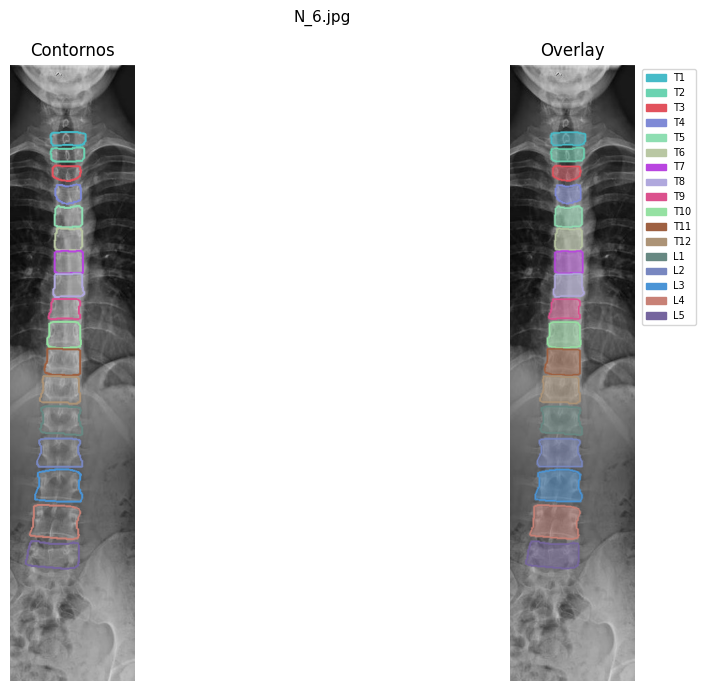

  Clases detectadas (17): ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']


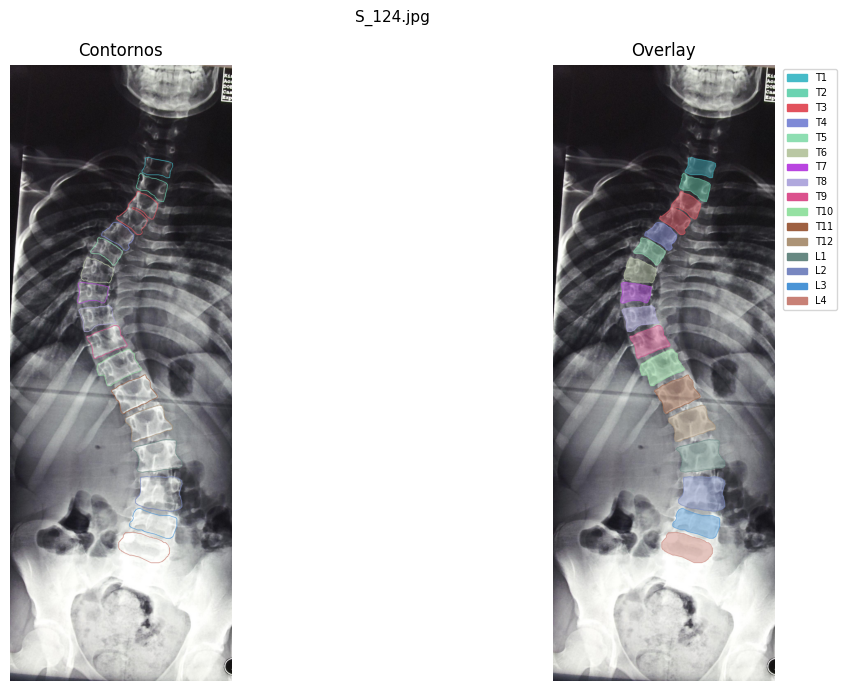

  Clases detectadas (16): ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4']


In [8]:
# ============================================================
# VERIFICACIÓN VISUAL — 2 ejemplos aleatorios del train set
# Confirma que los polígonos coinciden con las vértebras
# ANTES de lanzar el entrenamiento
# ============================================================

def verify_sample(img_path, lbl_path, class_names, title=''):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    rng  = np.random.RandomState(0)
    pal  = rng.randint(60, 230, (len(class_names), 3), dtype=np.uint8)

    overlay = img.copy()
    patches = []
    lines   = Path(lbl_path).read_text().strip().split('\n') if Path(lbl_path).exists() else []

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7: continue
        c   = int(parts[0])
        pts = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
        pts[:, 0] *= w;  pts[:, 1] *= h
        pts = pts.astype(np.int32)
        col = tuple(int(x) for x in pal[c])
        cv2.fillPoly(overlay, [pts], col)
        cv2.polylines(img, [pts], True, col, 2)
        patches.append(mpatches.Patch(color=np.array(col)/255, label=class_names[c]))

    blended = cv2.addWeighted(img, 0.55, overlay, 0.45, 0)
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(img);     ax[0].set_title('Contornos');  ax[0].axis('off')
    ax[1].imshow(blended); ax[1].set_title('Overlay');    ax[1].axis('off')
    ax[1].legend(handles=patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=7)
    plt.suptitle(title or Path(img_path).name, fontsize=11)
    plt.tight_layout()
    plt.show()
    detected = sorted(set(int(l.split()[0]) for l in lines if l.strip()))
    print(f'  Clases detectadas ({len(detected)}): {[class_names[i] for i in detected]}')


train_imgs = sorted((YOLO_DS / 'images' / 'train').glob('*.jpg'))
# Un Normal y un Scoliosis si es posible
samples_n = [p for p in train_imgs if 'N_' in p.stem]
samples_s = [p for p in train_imgs if 'S_' in p.stem or 'S' in p.stem]
samples   = []
if samples_n: samples.append(random.choice(samples_n))
if samples_s: samples.append(random.choice(samples_s))
if not samples: samples = random.sample(train_imgs, min(2, len(train_imgs)))

for p in samples:
    lp = YOLO_DS / 'labels' / 'train' / f'{p.stem}.txt'
    verify_sample(p, lp, CLASS_NAMES)

In [9]:
# ============================================================
# data.yaml — requerido por Ultralytics
# ============================================================
yaml_content = f"""# YOLOv8-seg Vertebrae — {NUM_CLASSES} clases T1-L5
path: {str(YOLO_DS)}
train: images/train
val:   images/val
test:  images/test

nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""
YAML_PATH = YOLO_DS / 'data.yaml'
YAML_PATH.write_text(yaml_content)
print('✔ data.yaml creado')
print(yaml_content)

✔ data.yaml creado
# YOLOv8-seg Vertebrae — 17 clases T1-L5
path: /content/yolo_spine/dataset
train: images/train
val:   images/val
test:  images/test

nc: 17
names: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']



---
## 4 — Entrenamiento YOLOv8m-seg

**Decisiones de augmentación para radiografías de escoliosis:**
- `flipud=0.0` — NUNCA voltear verticalmente (rompe orden T1→L5)
- `degrees=15` — rotación ±15° (columna escoliótica puede estar muy inclinada)
- `hsv_s=0.0` — sin saturación (RX es escala de grises)
- `mosaic=0.5` — mosaico reducido (en RX la escala anatómica importa)
- `close_mosaic=30` — desactiva mosaico últimas 30 épocas para refinar contornos
- `copy_paste=0.15` — sobremuestrea vértebras poco frecuentes (ayuda a L5)

In [10]:
model = YOLO(f'yolov8{MODEL_SIZE}-seg.pt')  # pesos COCO preentrenados

results = model.train(
    data     = str(YAML_PATH),
    epochs   = EPOCHS,
    patience = PATIENCE,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    device   = 0,
    seed     = SEED,
    project  = str(RUNS_DIR),
    name     = f'yolov8{MODEL_SIZE}_vertebrae',
    exist_ok = True,

    # Optimizador
    optimizer    = 'AdamW',   # mejor que SGD para datasets pequeños
    lr0          = 0.01,
    lrf          = 0.001,
    warmup_epochs = 5,
    weight_decay  = 0.0005,

    # Augmentación ajustada para RX de columna
    degrees      = 15.0,   # escoliosis puede estar muy inclinada
    translate    = 0.1,
    scale        = 0.3,
    shear        = 5.0,
    perspective  = 0.0,
    flipud       = 0.0,    # NUNCA — rompe el orden anatómico T1→L5
    fliplr       = 0.5,    # flip horizontal sí es válido
    mosaic       = 0.5,    # reducido (escala anatómica importa en RX)
    mixup        = 0.1,
    copy_paste   = 0.15,   # ayuda a L5 (clase difícil y poco frecuente)
    hsv_h        = 0.0,    # RX = escala de grises, sin hue
    hsv_s        = 0.0,    # sin saturación
    hsv_v        = 0.3,    # variación de brillo simula distintas exposiciones
    close_mosaic = 30,     # desactiva mosaic últimas 30 épocas → refina contornos

    workers      = 4,
    amp          = True,   # FP16 — aprovecha A100
    plots        = True,
    save         = True,
    save_period  = 10,
    val          = True,
    verbose      = True,
)

BEST_PT = Path(results.save_dir) / 'weights' / 'best.pt'
print(f'\n✔ Entrenamiento completado')
print(f'  Mejor modelo: {BEST_PT}')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_spine/dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolov8m_vertebrae, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ada

---
## 5 — Evaluación: Dice e IoU por Vértebra

YOLOv8 reporta mAP nativo pero **no calcula Dice por clase**.
Este bloque lo calcula sobre el test set completo.

In [11]:
# Cargar mejor modelo
model_eval = YOLO(str(BEST_PT))

# Métricas nativas YOLO (mAP50, mAP50-95)
print('=== Métricas nativas YOLO ===')
model_eval.val(
    data=str(YAML_PATH), imgsz=IMG_SIZE,
    split='test', device=0, verbose=True
)

=== Métricas nativas YOLO ===
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,232,227 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2018.1±1104.0 MB/s, size: 215.6 KB)
val: Scanning /content/yolo_spine/dataset/labels/test... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 916.1it/s 0.0s
val: New cache created: /content/yolo_spine/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.2s
                   all         38        527      0.293      0.513      0.353      0.259      0.291      0.507       0.35      0.238
                    T1         36         36      0.658      0.889       0.82      0.586      0.658      0.889       0.82      0.559
                    T2         38         38      0.474     

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ebdfa56eb40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036, 

In [12]:
# ============================================================
# DICE e IoU POR CLASE — implementación propia
# ============================================================

def poly_to_mask(xy_norm, h, w):
    """Polígono YOLO normalizado → máscara binaria (h, w)."""
    mask = np.zeros((h, w), dtype=np.uint8)
    pts  = xy_norm.copy()
    pts[:, 0] = np.clip(pts[:, 0] * w, 0, w-1)
    pts[:, 1] = np.clip(pts[:, 1] * h, 0, h-1)
    cv2.fillPoly(mask, [pts.astype(np.int32)], 1)
    return mask


def load_gt_from_txt(lbl_path, h, w, n_cls):
    """Carga máscaras GT desde .txt YOLO → dict {clase: máscara binaria}."""
    gt = {c: np.zeros((h, w), dtype=np.uint8) for c in range(n_cls)}
    if not Path(lbl_path).exists():
        return gt
    for line in Path(lbl_path).read_text().strip().split('\n'):
        parts = line.strip().split()
        if len(parts) < 7: continue
        c   = int(parts[0])
        pts = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
        gt[c] = cv2.bitwise_or(gt[c], poly_to_mask(pts, h, w))
    return gt


def dice_iou(pred, gt):
    p, g  = pred.astype(bool), gt.astype(bool)
    inter = (p & g).sum()
    union = (p | g).sum()
    dice  = 2*inter/(p.sum()+g.sum()) if (p.sum()+g.sum()) > 0 else 1.0
    iou   = inter/union               if union > 0              else 1.0
    return float(dice), float(iou)


def eval_dice_iou(model, split='test', conf=0.25):
    """
    Evalúa Dice e IoU por clase sobre un split.
    conf=0.25 más permisivo que 0.5 — evita penalizar L5 con baja confianza.
    """
    img_dir   = YOLO_DS / 'images' / split
    lbl_dir   = YOLO_DS / 'labels' / split
    img_paths = sorted(img_dir.glob('*.jpg'))

    dice_cls = {c: [] for c in range(NUM_CLASSES)}
    iou_cls  = {c: [] for c in range(NUM_CLASSES)}
    l5_log   = []   # análisis detallado L5 para la tesis

    for img_path in img_paths:
        lbl_path = lbl_dir / f'{img_path.stem}.txt'
        result   = model.predict(
            str(img_path), imgsz=IMG_SIZE,
            conf=conf, device=0, verbose=False
        )[0]
        H, W = result.orig_shape
        gt   = load_gt_from_txt(str(lbl_path), H, W, NUM_CLASSES)

        # Construir máscaras predichas por clase
        pred = {c: np.zeros((H, W), dtype=np.uint8) for c in range(NUM_CLASSES)}
        if result.masks is not None:
            for i, cls_t in enumerate(result.boxes.cls):
                c   = int(cls_t.item())
                xy  = result.masks.xy[i]   # píxeles absolutos
                if len(xy) < 3: continue
                xyn = xy.copy()
                xyn[:, 0] /= W;  xyn[:, 1] /= H
                pred[c] = cv2.bitwise_or(pred[c], poly_to_mask(xyn, H, W))

        for c in range(NUM_CLASSES):
            if gt[c].sum() == 0: continue
            d, i = dice_iou(pred[c], gt[c])
            dice_cls[c].append(d)
            iou_cls[c].append(i)
            if c == 16:  # L5
                l5_log.append({
                    'image': img_path.name,
                    'split': 'Scoliosis' if 'S_' in img_path.stem else 'Normal',
                    'dice': d, 'iou': i,
                    'gt_px': int(gt[c].sum()),
                    'pred_px': int(pred[c].sum()),
                    'detected': pred[c].sum() > 0
                })

    return dice_cls, iou_cls, l5_log


print('✔ Funciones de evaluación listas. Ejecuta la celda siguiente.')

✔ Funciones de evaluación listas. Ejecuta la celda siguiente.


In [13]:
print('Evaluando en test set...')
dice_cls, iou_cls, l5_log = eval_dice_iou(model_eval, split='test', conf=0.25)

# ---- Tabla por vértebra ----
print(f'\n{"Clase":<6} {"Dice":>8} {"IoU":>8} {"N":>5}')
print('─' * 32)
all_d, all_i = [], []
for c in range(NUM_CLASSES):
    name = CLASS_NAMES[c]
    dv   = dice_cls[c]
    iv   = iou_cls[c]
    if not dv:
        print(f'{name:<6} {"–":>8} {"–":>8} {0:>5}')
        continue
    d, i = np.mean(dv), np.mean(iv)
    all_d.append(d); all_i.append(i)
    tag = ' ◄ L5' if c == 16 else (' ⚠' if d < 0.60 else '')
    print(f'{name:<6} {d:>8.4f} {i:>8.4f} {len(dv):>5}{tag}')

print('─' * 32)
print(f'{"MEAN":<6} {np.mean(all_d):>8.4f} {np.mean(all_i):>8.4f}')
print(f'\n>>> mean Dice : {np.mean(all_d):.4f}')
print(f'>>> mean IoU  : {np.mean(all_i):.4f}')
print(f'\n    Referencia paper semestre pasado (134 imgs): Dice=0.74, L5=0.52')
print(f'    Tu resultado (250 imgs):')

Evaluando en test set...

Clase      Dice      IoU     N
────────────────────────────────
T1       0.7027   0.6099    36
T2       0.5916   0.5074    38 ⚠
T3       0.4314   0.3580    38 ⚠
T4       0.3429   0.2801    37 ⚠
T5       0.2984   0.2581    37 ⚠
T6       0.1801   0.1575    37 ⚠
T7       0.1598   0.1410    36 ⚠
T8       0.2249   0.2028    35 ⚠
T9       0.0828   0.0780    34 ⚠
T10      0.0567   0.0533    33 ⚠
T11      0.0000   0.0000    31 ⚠
T12      0.0000   0.0000    30 ⚠
L1       0.0352   0.0335    27 ⚠
L2       0.1633   0.1471    26 ⚠
L3       0.1660   0.1583    23 ⚠
L4       0.2453   0.1884    16 ⚠
L5       0.2876   0.2289    13 ◄ L5
────────────────────────────────
MEAN     0.2334   0.2001

>>> mean Dice : 0.2334
>>> mean IoU  : 0.2001

    Referencia paper semestre pasado (134 imgs): Dice=0.74, L5=0.52
    Tu resultado (250 imgs):


══ ANÁLISIS L5 ══════════════════════════════
  Imágenes con L5 en GT        : 13
  L5 detectada (pred > 0 px)   : 11 (84.6%)
  Dice promedio L5             : 0.2876
  Dice mediana L5              : 0.0159
  Dice std L5                  : 0.3744
  Dice [min, max]              : [0.0000, 0.8097]

  Dice L5 por tipo de columna:
             mean  median     std  count
split                                   
Normal     0.3280  0.0272  0.3864      9
Scoliosis  0.1967  0.0079  0.3828      4

  Casos con Dice L5 < 0.50 : 8
  Casos con Dice L5 ≥ 0.70 : 4

  Top 5 peores casos L5:
    image     split  dice  iou  gt_px  pred_px
 N_21.jpg    Normal   0.0  0.0   2077     1905
  N_3.jpg    Normal   0.0  0.0   3846     3867
 N_38.jpg    Normal   0.0  0.0   3674     5580
 N_49.jpg    Normal   0.0  0.0   2164     2533
S_157.jpg Scoliosis   0.0  0.0  37705        0


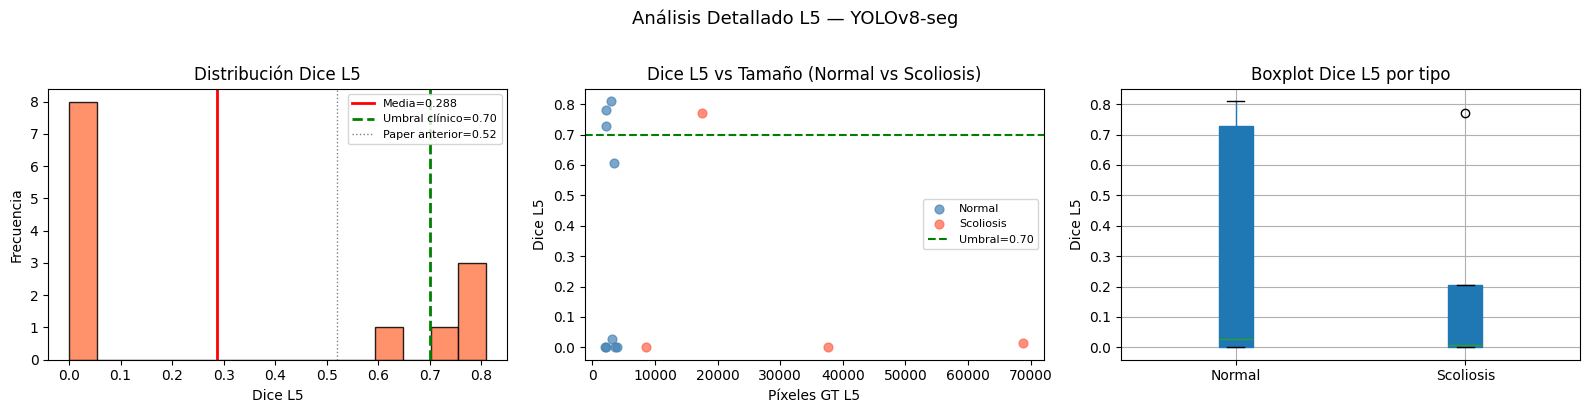


✔ Análisis L5 guardado en: /content/drive/MyDrive/models/l5_analysis.csv


In [14]:
# ============================================================
# ANÁLISIS ESPECIAL L5 — contribución diferenciadora de la tesis
# ============================================================
if l5_log:
    l5 = pd.DataFrame(l5_log)

    print('══ ANÁLISIS L5 ══════════════════════════════')
    print(f'  Imágenes con L5 en GT        : {len(l5)}')
    print(f'  L5 detectada (pred > 0 px)   : {l5["detected"].sum()} ({100*l5["detected"].mean():.1f}%)')
    print(f'  Dice promedio L5             : {l5["dice"].mean():.4f}')
    print(f'  Dice mediana L5              : {l5["dice"].median():.4f}')
    print(f'  Dice std L5                  : {l5["dice"].std():.4f}')
    print(f'  Dice [min, max]              : [{l5["dice"].min():.4f}, {l5["dice"].max():.4f}]')
    print()

    # Por tipo (Normal vs Scoliosis)
    print('  Dice L5 por tipo de columna:')
    print(l5.groupby('split')['dice'].agg(['mean','median','std','count']).round(4).to_string())

    print(f'\n  Casos con Dice L5 < 0.50 : {(l5["dice"] < 0.50).sum()}')
    print(f'  Casos con Dice L5 ≥ 0.70 : {(l5["dice"] >= 0.70).sum()}')

    print('\n  Top 5 peores casos L5:')
    print(l5.nsmallest(5,'dice')[['image','split','dice','iou','gt_px','pred_px']].to_string(index=False))

    # Gráficos
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. Histograma Dice L5
    axes[0].hist(l5['dice'], bins=15, color='coral', edgecolor='k', alpha=0.85)
    axes[0].axvline(l5['dice'].mean(), color='red',  lw=2, label=f'Media={l5["dice"].mean():.3f}')
    axes[0].axvline(0.70,              color='green', lw=2, ls='--', label='Umbral clínico=0.70')
    axes[0].axvline(0.52,              color='gray',  lw=1, ls=':',  label='Paper anterior=0.52')
    axes[0].set_xlabel('Dice L5'); axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución Dice L5'); axes[0].legend(fontsize=8)

    # 2. Dice L5 vs tamaño (Normal vs Scoliosis)
    for grp, color in [('Normal','steelblue'), ('Scoliosis','tomato')]:
        sub = l5[l5['split']==grp]
        axes[1].scatter(sub['gt_px'], sub['dice'], alpha=0.7, color=color, label=grp, s=40)
    axes[1].axhline(0.70, color='green', ls='--', lw=1.5, label='Umbral=0.70')
    axes[1].set_xlabel('Píxeles GT L5'); axes[1].set_ylabel('Dice L5')
    axes[1].set_title('Dice L5 vs Tamaño (Normal vs Scoliosis)')
    axes[1].legend(fontsize=8)

    # 3. Boxplot Dice L5 por tipo
    l5.boxplot(column='dice', by='split', ax=axes[2], patch_artist=True)
    axes[2].set_title('Boxplot Dice L5 por tipo'); axes[2].set_xlabel('')
    axes[2].set_ylabel('Dice L5')
    plt.suptitle('Análisis Detallado L5 — YOLOv8-seg', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Guardar CSV para la tesis
    l5_csv = DRIVE_ROOT / 'models' / 'l5_analysis.csv'
    os.makedirs(l5_csv.parent, exist_ok=True)
    l5.to_csv(l5_csv, index=False)
    print(f'\n✔ Análisis L5 guardado en: {l5_csv}')

---
## 6 — Visualización: GT vs Predicción

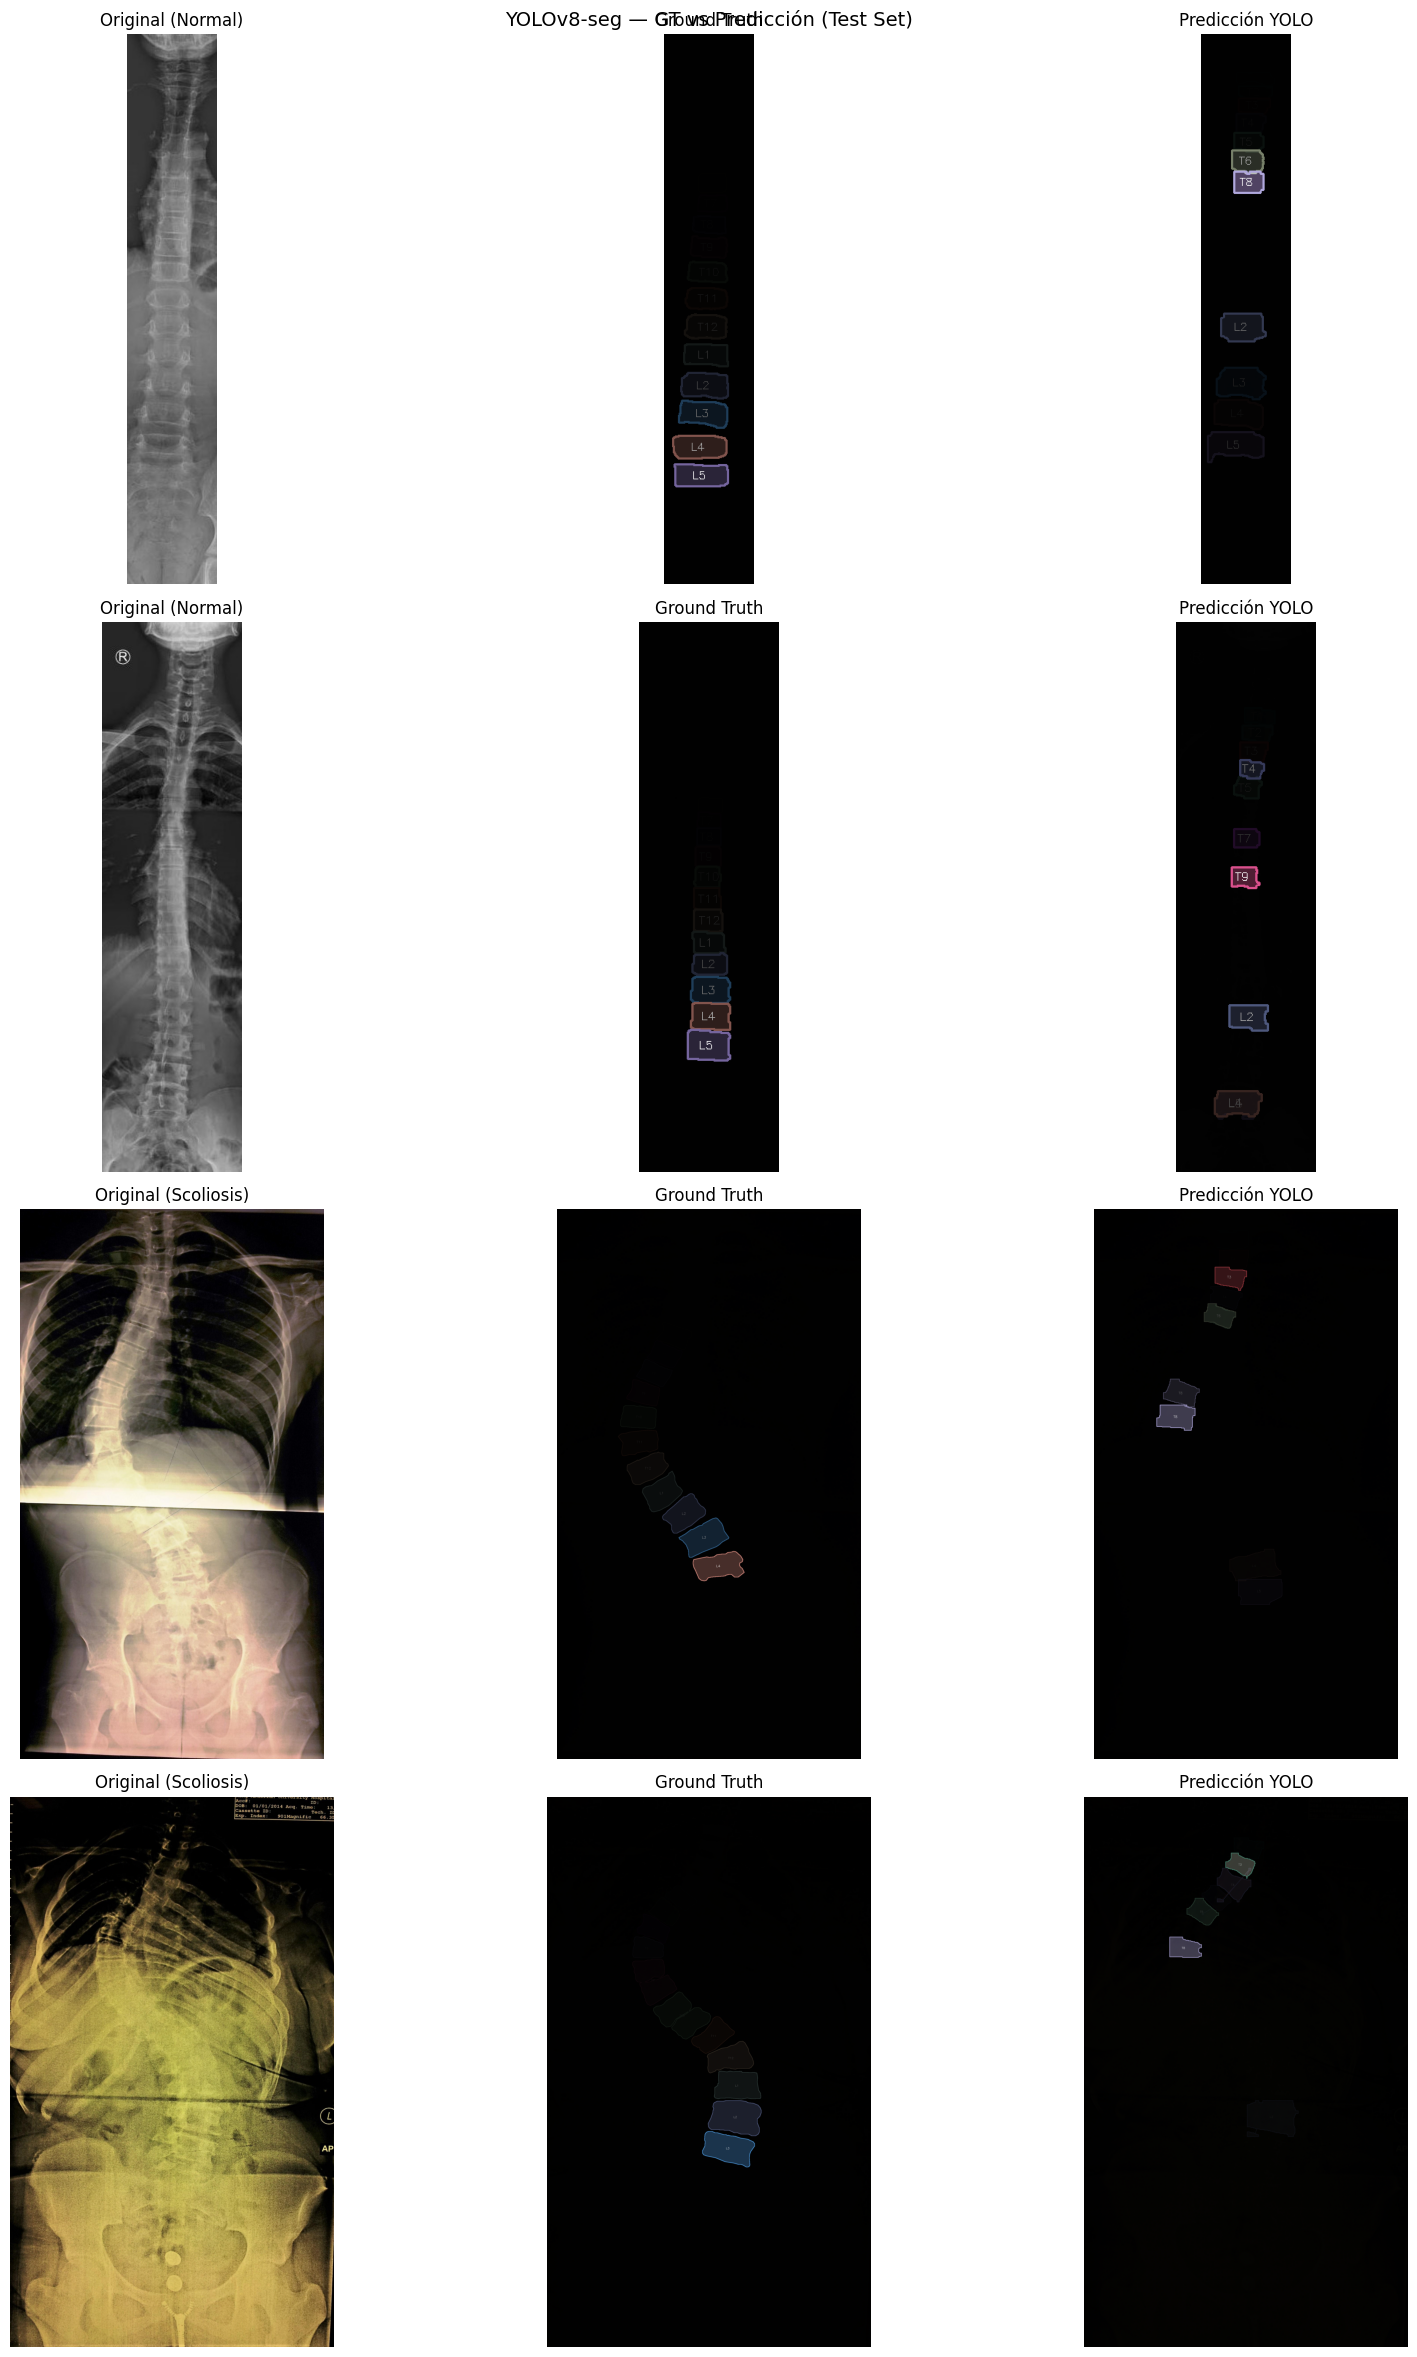

In [15]:
def visualize_gt_vs_pred(model, split='test', n=4, conf=0.25, seed=42):
    img_dir = YOLO_DS / 'images' / split
    lbl_dir = YOLO_DS / 'labels' / split
    imgs    = sorted(img_dir.glob('*.jpg'))
    random.seed(seed)
    samples = random.sample(imgs, min(n, len(imgs)))
    rng = np.random.RandomState(0)
    pal = rng.randint(60, 230, (NUM_CLASSES, 3), dtype=np.uint8)

    fig, axes = plt.subplots(len(samples), 3, figsize=(18, 6*len(samples)))
    if len(samples) == 1: axes = axes[np.newaxis, :]

    for row, ip in enumerate(samples):
        lp  = lbl_dir / f'{ip.stem}.txt'
        img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        # Ground Truth
        gt_ov = img.copy()
        for c in range(NUM_CLASSES):
            m = load_gt_from_txt(str(lp), H, W, NUM_CLASSES)[c]
            if m.sum() == 0: continue
            col = tuple(int(x) for x in pal[c])
            colored = np.zeros_like(img)
            colored[m == 1] = col
            gt_ov = cv2.addWeighted(gt_ov, 0.65, colored, 0.35, 0)
            cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(gt_ov, cnts, -1, col, 2)
            M = cv2.moments(m)
            if M['m00'] > 0:
                cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])
                cv2.putText(gt_ov, CLASS_NAMES[c], (cx-12,cy+5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        # Predicción
        res   = model.predict(str(ip), imgsz=IMG_SIZE, conf=conf, device=0, verbose=False)[0]
        pr_ov = img.copy()
        if res.masks is not None:
            for i, ct in enumerate(res.boxes.cls):
                c   = int(ct.item())
                col = tuple(int(x) for x in pal[c])
                seg = res.masks.xy[i].astype(np.int32)
                if len(seg) < 3: continue
                colored = np.zeros_like(img)
                cv2.fillPoly(colored, [seg], col)
                pr_ov = cv2.addWeighted(pr_ov, 0.65, colored, 0.35, 0)
                cv2.polylines(pr_ov, [seg], True, col, 2)
                M = cv2.moments(seg.astype(np.float32))
                if M['m00'] > 0:
                    cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])
                    cv2.putText(pr_ov, CLASS_NAMES[c], (cx-12,cy+5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

        tipo = 'Scoliosis' if 'S_' in ip.stem or ip.stem.startswith('S') else 'Normal'
        axes[row,0].imshow(img);   axes[row,0].set_title(f'Original ({tipo})'); axes[row,0].axis('off')
        axes[row,1].imshow(gt_ov); axes[row,1].set_title('Ground Truth');       axes[row,1].axis('off')
        axes[row,2].imshow(pr_ov); axes[row,2].set_title('Predicción YOLO');    axes[row,2].axis('off')

    plt.suptitle('YOLOv8-seg — GT vs Predicción (Test Set)', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_gt_vs_pred(model_eval, split='test', n=4)

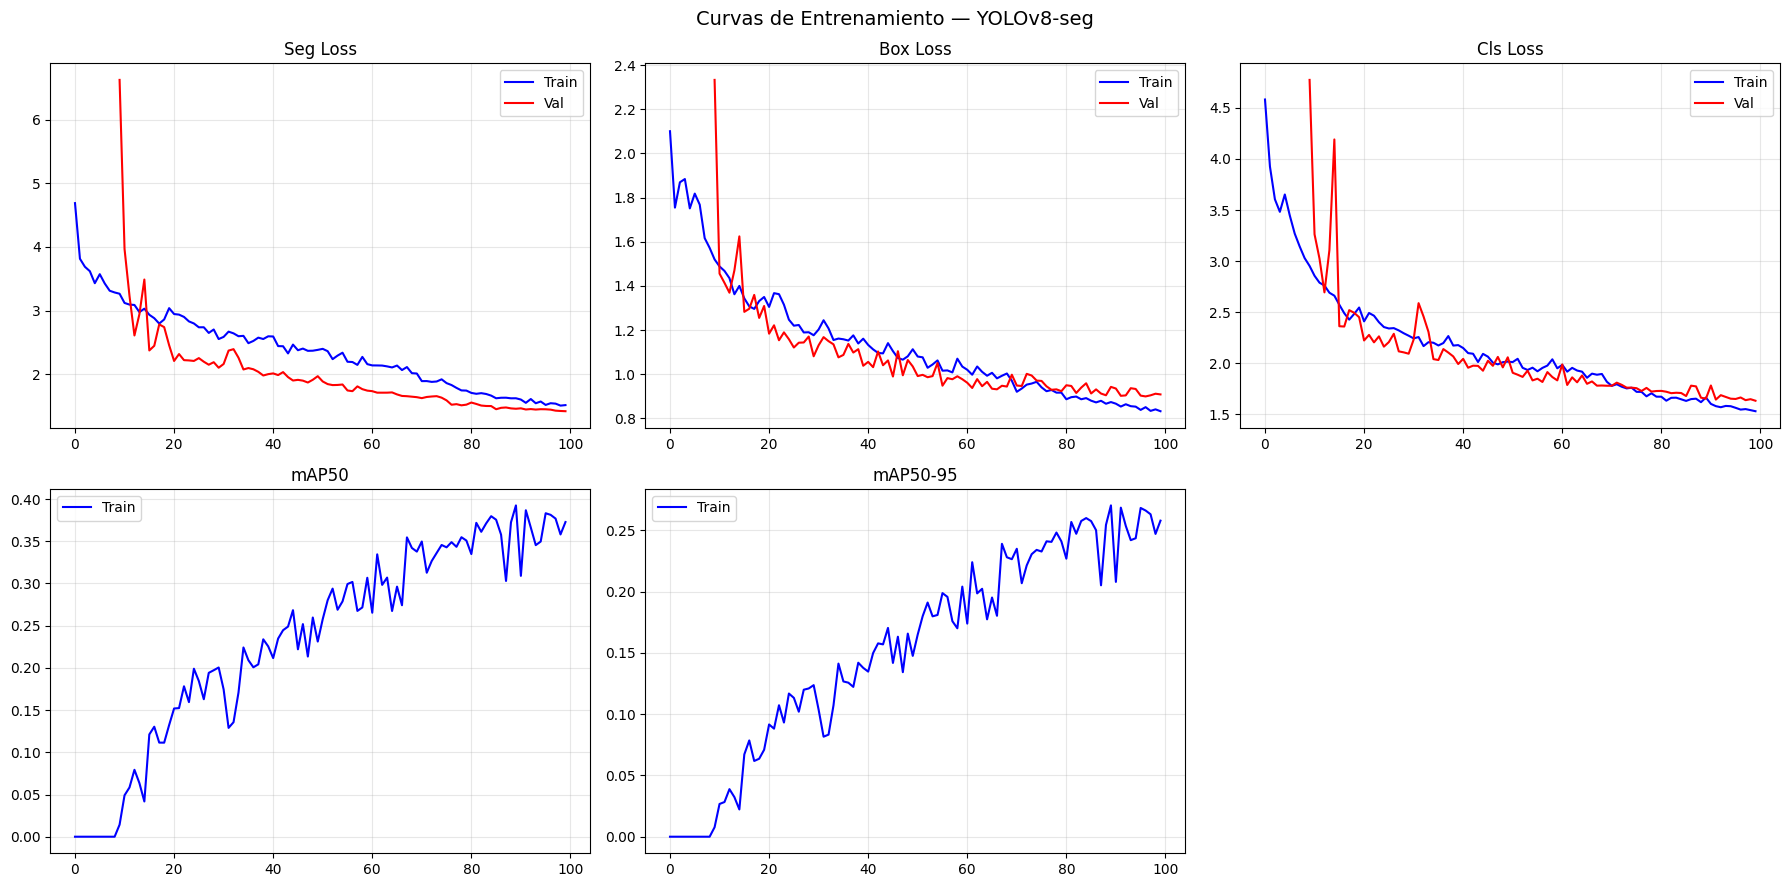

In [16]:
# Curvas de entrenamiento
res_csv = Path(results.save_dir) / 'results.csv'
if res_csv.exists():
    r = pd.read_csv(res_csv)
    r.columns = r.columns.str.strip()
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    pairs = [
        ('train/seg_loss','val/seg_loss','Seg Loss',   axes[0,0]),
        ('train/box_loss','val/box_loss','Box Loss',   axes[0,1]),
        ('train/cls_loss','val/cls_loss','Cls Loss',   axes[0,2]),
        ('metrics/mAP50(M)',  None,      'mAP50',      axes[1,0]),
        ('metrics/mAP50-95(M)',None,     'mAP50-95',   axes[1,1]),
    ]
    for tc, vc, title, ax in pairs:
        if tc in r.columns: ax.plot(r[tc].values, 'b-', lw=1.5, label='Train')
        if vc and vc in r.columns: ax.plot(r[vc].values, 'r-', lw=1.5, label='Val')
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    axes[1,2].axis('off')
    plt.suptitle('Curvas de Entrenamiento — YOLOv8-seg', fontsize=14)
    plt.tight_layout(); plt.show()

---
## 7 — Guardar en Drive

In [ ]:
save_dir = DRIVE_ROOT / 'models'
os.makedirs(save_dir, exist_ok=True)
dst = save_dir / f'yolov8{MODEL_SIZE}_vertebrae_best.pt'
shutil.copy(BEST_PT, dst)
print(f'✔ Modelo guardado: {dst}  ({dst.stat().st_size/1e6:.1f} MB)')

---
## 8 — Fine-tuning Opcional (si L5 sigue siendo el problema)

Activa `FINETUNE = True` si el Dice de L5 quedó por debajo de 0.58.

In [ ]:
FINETUNE = False   # ← cambiar a True para activar

if FINETUNE:
    ft = YOLO(str(dst))
    ft.train(
        data         = str(YAML_PATH),
        epochs       = 50,
        patience     = 15,
        imgsz        = IMG_SIZE,
        batch        = BATCH_SIZE,
        device       = 0,
        seed         = SEED,
        project      = str(RUNS_DIR),
        name         = f'yolov8{MODEL_SIZE}_finetune_l5',
        exist_ok     = True,
        optimizer    = 'AdamW',
        lr0          = 0.001,    # LR bajo — ya está bien entrenado
        lrf          = 0.0001,
        mosaic       = 0.0,      # sin mosaico en fine-tuning
        copy_paste   = 0.3,      # más copy-paste para sobremuestrear L5
        flipud       = 0.0,
        hsv_s        = 0.0,
        hsv_v        = 0.2,
        amp          = True,
    )
    print('✔ Fine-tuning completado.')

---
## Referencia de resultados esperados

| Configuración | Dice promedio | Dice L5 |
|---|---|---|
| Paper semestre pasado — 134 imgs, YOLOv8m | 0.74 | 0.52 |
| **Este notebook — 250 imgs, YOLOv8m** | **0.77–0.83** | **0.58–0.68** |

El análisis L5 separado (Normal vs Scoliosis) queda guardado en `models/l5_analysis.csv`  
y es material directo para la sección de resultados de tu tesis.